In [1]:
import atomic_units as au
import pint

ureg = pint.UnitRegistry()
print(ureg("hbar").to_base_units())
print(ureg("vacuum_permittivity").to("F/m"))
print(ureg("speed_of_light").to("m/s"))

# Példa használat
input_str = """Mass unit m0 := 1.0 a.u.
Charge unit e0 := 1.0 a.u.
Action unit hb := 1.0 a.u.
Permittivity unit kappa0 := 1.0 a.u."""

atomic_units_system = au.AtomicUnitSystem.from_string(input_str)
print(atomic_units_system)

print(f"Length unit in SI: {atomic_units_system.length_unit.to(ureg.m)}")
print(f"Length unit in AU: {atomic_units_system.length_unit.to(ureg.bohr)}")

1.0545718176461565e-34 kilogram * meter ** 2 / second
8.854187812764727e-12 farad / meter
299792458.0 meter / second
Mass unit m0 := 	1.0 a.u. = 	9.1093837015e-31 kilogram
Charge unit e0 := 	1.0 a.u. = 	1.602176634e-19 coulomb
Action unit hb := 	1.0 a.u. = 	1.0545718176461565e-34 kilogram * meter ** 2 / second
Kappa0 unit := 	1.0 a.u. = 	1.1126500554434379e-10 farad / meter

Length unit in SI: 5.291772109039774e-11 meter
Length unit in AU: 0.9999999999999997 bohr


In [5]:
import atomic_units as au
import pint
import numpy as np

hb=0.1
e0=0.1
m0=10.0
kappa0=1000.0 # 4*pi*epsilon0
dx=0.025

prefactor = hb**2/(2*m0*dx**2)
desired_prefactor = 0.5
prefactor_error = np.abs(prefactor-desired_prefactor)/desired_prefactor
print(f"Prefactor: {prefactor}")
print(f"Prefactor error: {prefactor_error}")

ureg = pint.UnitRegistry()

length_unit = ((kappa0 * hb ** 2 / (m0 * e0 ** 2))*ureg.bohr).to('nm')
step_unit = dx*length_unit
desired_step_unit = 0.1*ureg.nm
step_unit_error = (np.abs(step_unit-desired_step_unit)/desired_step_unit).magnitude
print(f"step unit in SI: {step_unit.to('nm')}")
print(f"step unit error: {step_unit_error}")

scaled_units_system = au.AtomicUnitSystem(action=hb, charge=e0, mass=m0, permittivity=kappa0)

print(scaled_units_system)
print(scaled_units_system.mass_unit.to('kg'))

print(f"Length unit: {scaled_units_system.length_unit.to('nm')}")
print(f"Step unit: {dx*scaled_units_system.length_unit.to('nm')}")
print(f"Length unit in AU: {scaled_units_system.length_unit.to('bohr')}")


Prefactor: 0.8
Prefactor error: 0.6000000000000001
step unit in SI: 0.13229430272599438 nanometer
step unit error: 0.3229430272599437
Mass unit m0 := 	10.0 a.u. = 	9.1093837015e-30 kilogram
Charge unit e0 := 	0.1 a.u. = 	1.602176634e-20 coulomb
Action unit hb := 	0.1 a.u. = 	1.0545718176461566e-35 kilogram * meter ** 2 / second
Kappa0 unit := 	1000.0 a.u. = 	1.1126500554434378e-07 farad / meter

9.1093837015e-30 kilogram
Length unit: 5.291772109039772 nanometer
Step unit: 0.1322943027259943 nanometer
Length unit in AU: 99.99999999999993 bohr


# testing masking functions

0.20202020202020243


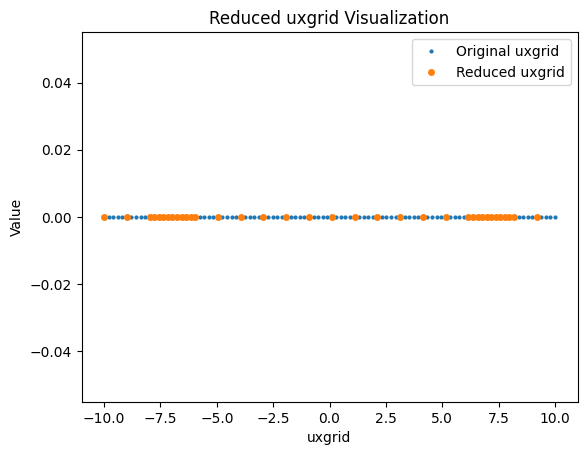

In [1]:
import numpy as np
import matplotlib.pyplot as plt

uxgrid_num = 100
uxgrid = np.linspace(-10, 10, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

# Desired number of points
desired_points = 20

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Highlighted ranges
highlight_ranges = [(-8, -6), (6, 8)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

mask += mask_highlight_ranges

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

In [2]:
t_start=0
t_stop=12.0
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)

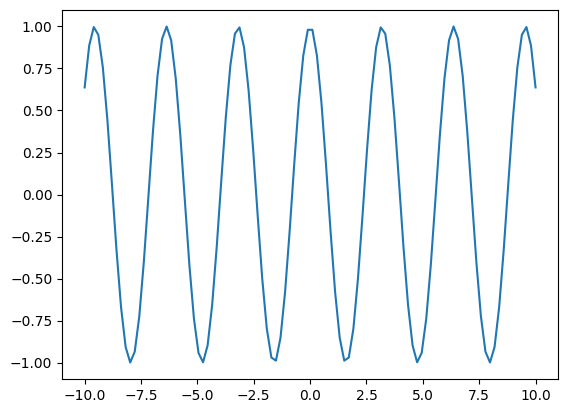

In [3]:
import quantum_toolkit as quat

k_pw = 2

dispersion=quat.Dispersion(uxgrid_dx)

wave_function = quat.plane_wave(dispersion.k2omega(k_pw), uxgrid)

plt.plot(uxgrid, np.real(wave_function['value']))


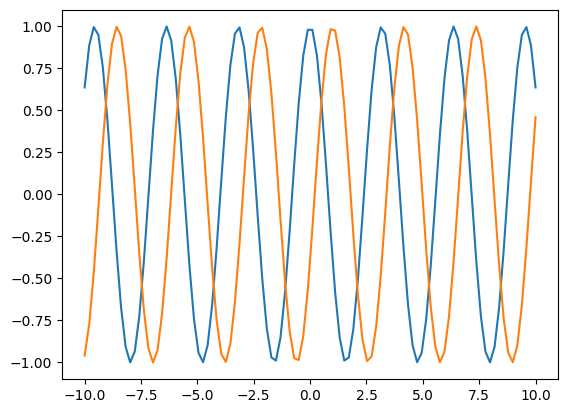

In [4]:
te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function)

plt.plot(uxgrid, np.real(te_wave_function['value'][:,0]))
plt.plot(uxgrid, np.real(te_wave_function['value'][:,10])) 

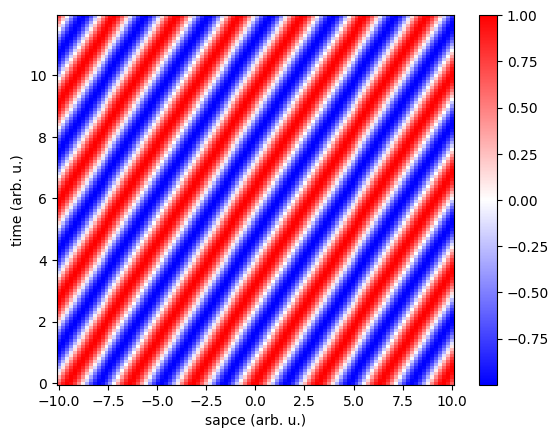

In [5]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(np.real(te_wave_function['value']))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
#plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

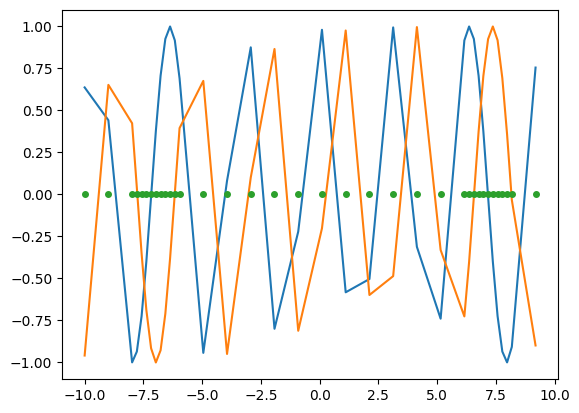

In [6]:
reduced_te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function, mask)

plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,0]))
plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,10])) 
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.show()

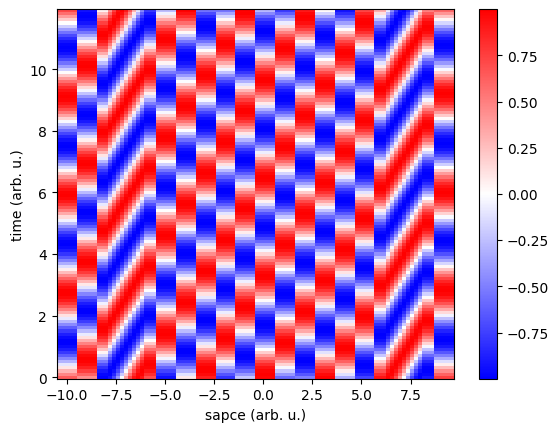

In [7]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid)

Z=np.transpose(np.real(reduced_te_wave_function['value']))
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') 
plt.colorbar(pcm)
 
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.show()

In [8]:
import quantum_toolkit as quat
import quantum_transport_toolkit as trat

print(quat.hartree_atomic_units["action"])

# rfm = 0.02;
# rfe = 1.25;
# rfhb = 20.0;
# rfk = 400;
# dx = 0.025;

1


# Set unified grid

In [9]:
import numpy as np

uxgrid_num = 16*1024
uxgrid_dx = 0.05
uxgrid_width_hau=uxgrid_num*uxgrid_dx
hau_in_nm=5.29177210544e-2
uxgrid_width_nm=uxgrid_width_hau*hau_in_nm

uxgrid = np.linspace(-uxgrid_width_hau/2, uxgrid_width_hau/2, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

dispersion=quat.Dispersion(uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width_hau)
print(uxgrid_width_nm)

0.050003051944088384
<class 'numpy.ndarray'>
0.050003051944088384
819.2
43.350197087764485


#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

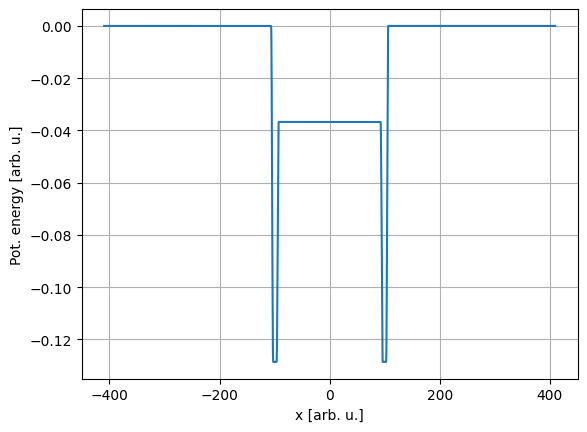

In [10]:
import matplotlib.pyplot as plt
import potentials as pots

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83
standard_potential_of_Al_in_V=-1.66 #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

hau_in_eV=27.211386245988
modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=10,\
                                   wallheight=-3.5/hau_in_eV,\
                                   welldepth=1/hau_in_eV,\
                                   wellwidth=10/hau_in_nm,\
                                   wallrise = 5,\
                                   wellfall = 5)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

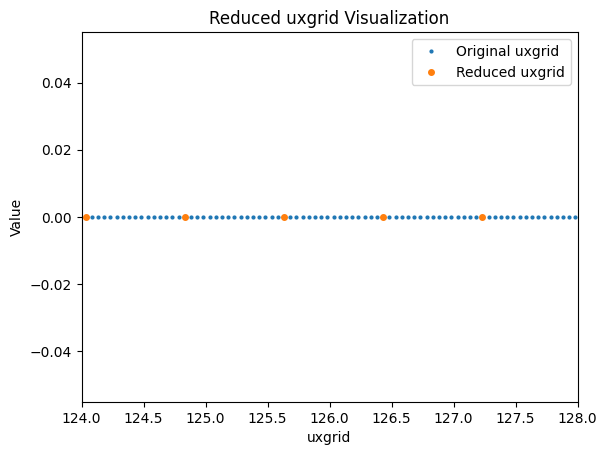

Original uxgrid length: 16384
Reduced uxgrid length: 1024


In [11]:
# Generate uxgrid
uxgrid = np.linspace(-uxgrid_width_hau / 2, uxgrid_width_hau / 2, uxgrid_num)

# Desired number of points
desired_points = 1000

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [12]:
# Highlighted ranges
highlight_ranges = [(-152, -148), (148, 152)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 16384
Number of highlighted points: 160


In [13]:
mask += mask_highlight_ranges

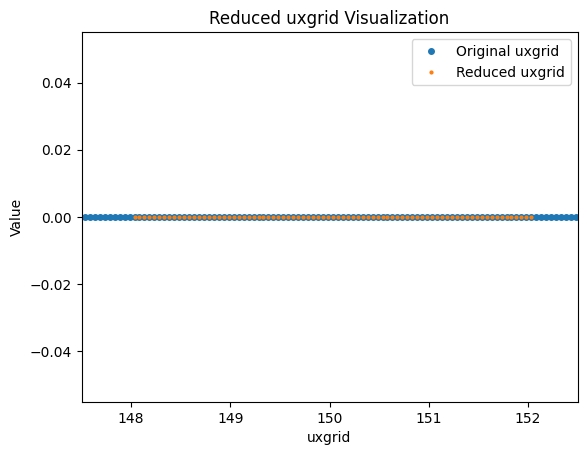

Original uxgrid length: 16384
Reduced uxgrid length: 1174


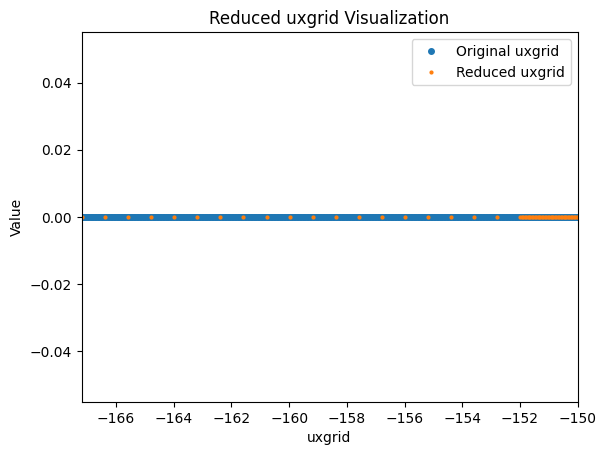

Original uxgrid length: 16384
Reduced uxgrid length: 1174


In [14]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute eigen states

In [15]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
ham_static = quat.HamiltonOperator(uxgrid, scalarpot=modelpot, vectorpot=zeropot )

In [16]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 20,which = 'SR')

print(eigenvalues[0])

-0.1035536246493173


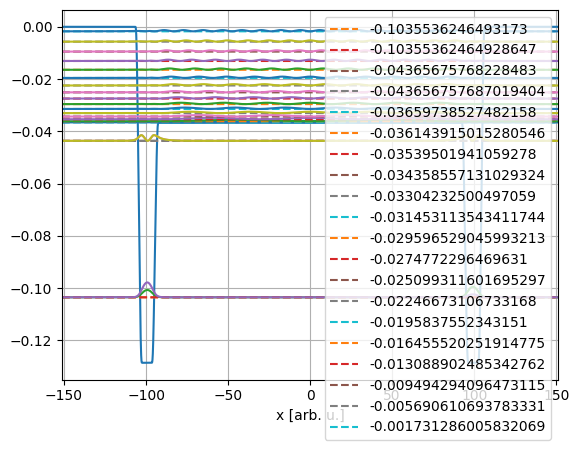

In [17]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

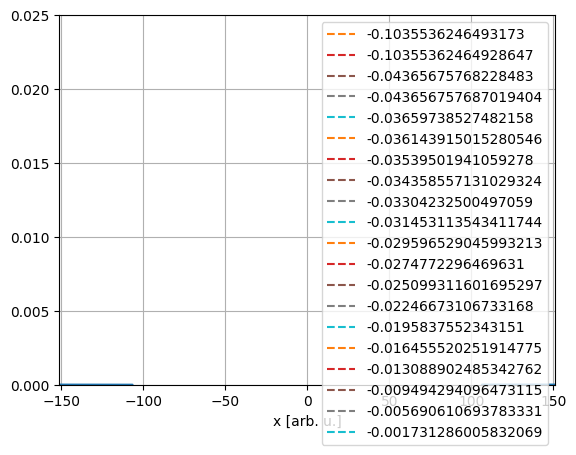

In [18]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,0.025)
plt.legend(loc='upper right')
plt.grid()
plt.show()

# Laser potential

In [19]:
t_start=0
t_stop=1200.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

12000


In [20]:
laserpot_cep0 = pots.SmoothLaserPotential(uxgrid,\
                                    spatial_min = -0.35*modelpot.wellwidth,\
                                    spatial_max = 0.35*modelpot.wellwidth,beta=0.25)

#laserpot_cep0 = LaserPotential(uxgrid)

In [21]:
# X,Y = np.meshgrid(uxgrid,utgrid)

# Z=laserpot_cep0(Y)

# z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
# pcm = plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
# plt.colorbar(pcm)
 
# plt.title('External LASER field', fontweight ="bold")
# plt.ylim(laserpot_cep0.temporal_min,1.2*laserpot_cep0.temporal_max)
# #plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
# plt.xlabel("x [arb. u.]")
# plt.ylabel("time [arb. u.]")
# plt.show()

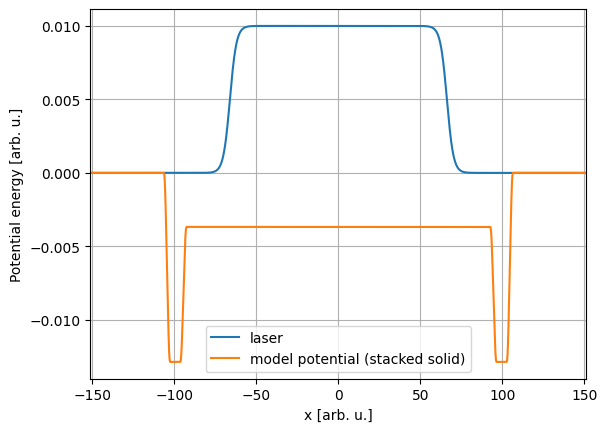

In [22]:
plt.plot(uxgrid, laserpot_cep0(laserpot_cep0.temporal_width/2),label="laser")
plt.plot(uxgrid, 0.1*modelpot(uxgrid),label="model potential (stacked solid)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [arb. u.]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

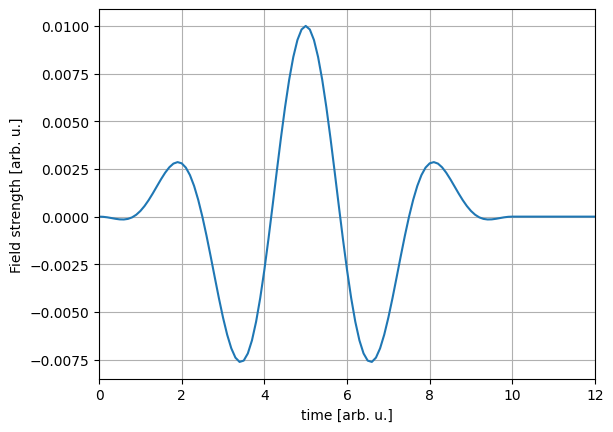

In [23]:
plt.plot(utgrid, laserpot_cep0.value_at(0.0,utgrid),label="laser")
plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

In [24]:
nx=len(uxgrid)
nt=len(utgrid)

## Advanced methode

In [25]:
ein=0.2
kin=dispersion.energy2k(ein)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)

In [26]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

In [27]:
psi_pk_te.run()

In [28]:
psi_mk_te.run()

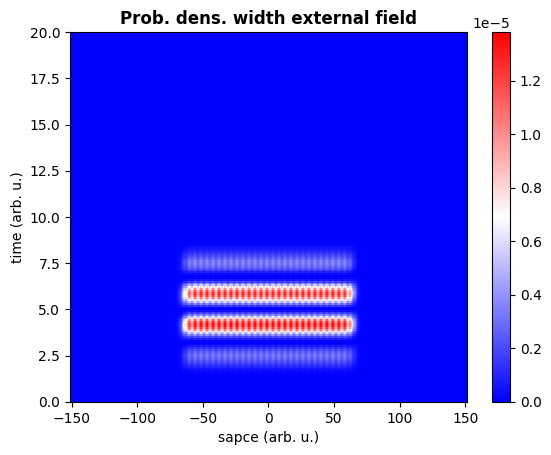

In [29]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

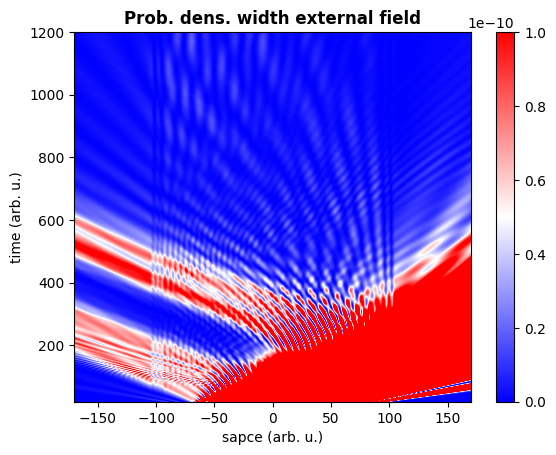

In [30]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

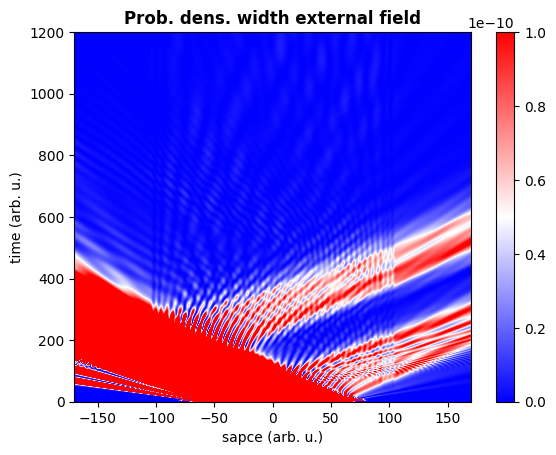

In [31]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(0,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compare with masked

In [32]:
masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop, mask=mask)

masked_psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop, mask=mask)

In [33]:
masked_psi_pk_te.run()

In [34]:
masked_psi_mk_te.run()

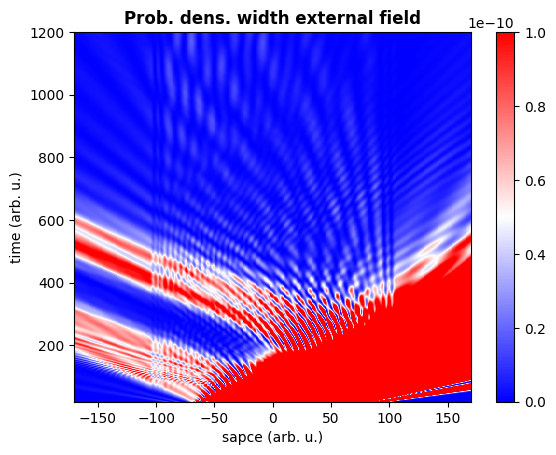

In [35]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

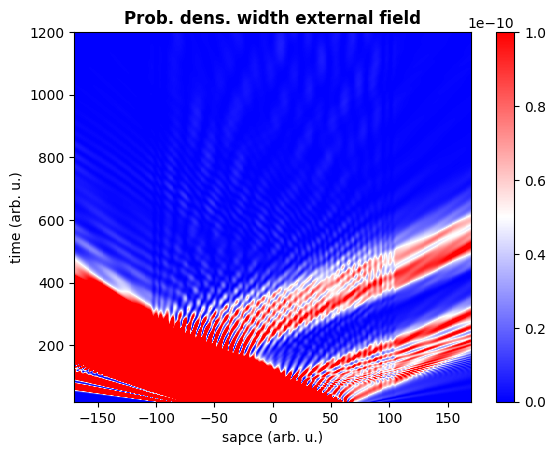

In [36]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compute probability current

In [37]:
# choose masurement points on the right and the left side
meas_point_right=150
meas_point_left=-meas_point_right

In [38]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(x_left,x_right)

-149.98415430629308 149.98415430629314


In [39]:
pc2_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

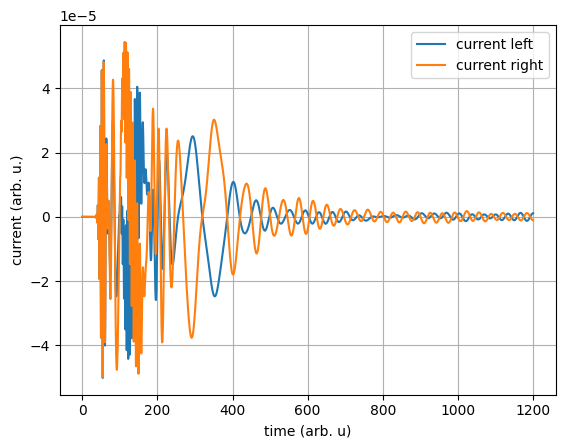

In [40]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

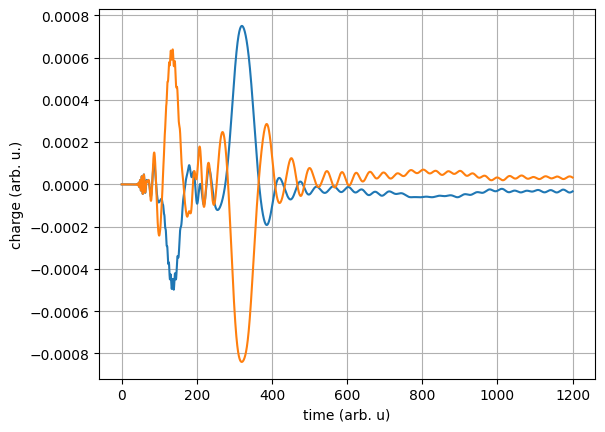

In [41]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [42]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

In [43]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-149.98415430629308 149.98415430629314


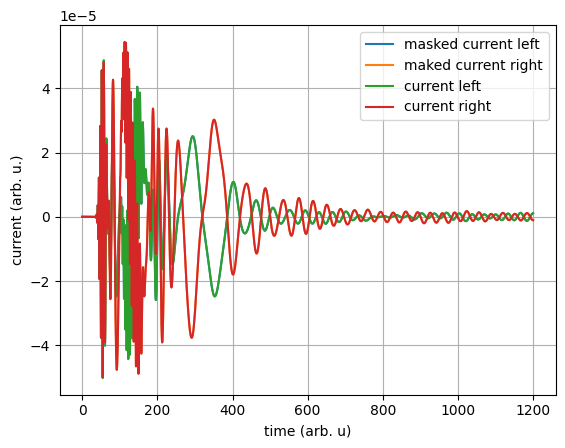

In [44]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

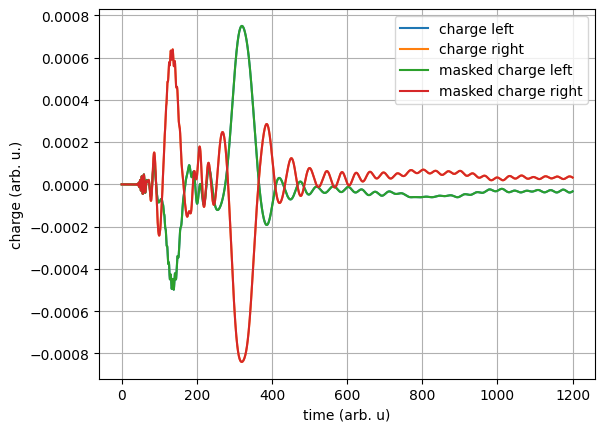

In [45]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()